# Deep Clustering

<a id="1"></a>

## Imports


In [1]:
import numpy as np
import torch 
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tqdm import tqdm 
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
import copy
import random
from k_means_constrained import KMeansConstrained
from sklearn.svm import SVC
import pandas as pd

/home/tom/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/tom/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


<a id="2"></a>

### Read in and Preprocess Data

In [2]:
query_1 = pd.read_csv('/home/tom/Documents/ParlayPlay/Data_pulled_24_jan/query_1.csv')
query_2 = pd.read_csv('/home/tom/Documents/ParlayPlay/Data_pulled_24_jan/query_2.csv')
query_3 = pd.read_csv('/home/tom/Documents/ParlayPlay/Data_pulled_24_jan/query_3.csv')
query_4 = pd.read_csv('/home/tom/Documents/ParlayPlay/Data_pulled_24_jan/query_4.csv')
query_5 = pd.read_csv('/home/tom/Documents/ParlayPlay/Data_pulled_24_jan/query_5.csv')
query_6 = pd.read_csv('/home/tom/Documents/ParlayPlay/Data_pulled_24_jan/query_6.csv')
new_coupon_data = pd.read_csv('/home/tom/Documents/ParlayPlay/Data_pulled_24_jan/new_coupon_desg_data.csv')

In [3]:
df_raw = pd.merge(query_1, query_2, how='left', left_on='id', right_on = 'username_id')
df_raw = pd.merge(df_raw, query_3, how='left', on='username')
df_raw = pd.merge(df_raw, query_4, how='left', on='id')
df_raw = pd.merge(df_raw, query_5, how='left', left_on='id', right_on = 'username_id')
df_raw = pd.merge(df_raw, query_6, how='left', on='username')
df_raw = df_raw.drop(columns = ['coupon_designation'])
df_raw = pd.merge(df_raw, new_coupon_data, how='left', on='username')

In [4]:
df_raw.shape

(314731, 34)

In [5]:
df_ftd_raw = df_raw[df_raw['is_ftd'] == True]

In [6]:
df_ftd_raw = df_ftd_raw.fillna(0)

In [7]:
ltv_bins = [-1000000, -0.1, 0, 25, 50, 100, 1000000]

df_ftd_raw['ltv_binned'] = pd.cut(df_ftd_raw['net_cash'], ltv_bins)

In [8]:
contest_count_bins = [-1, 0, 5, 10, 20, 30, 50, 75, 100, 200, 1000000]

df_ftd_raw['contest_count_binned'] = pd.cut(df_ftd_raw['contest_count'], contest_count_bins)

In [9]:
df_ftd_raw = df_ftd_raw.drop(columns = ['contest_count', 'net_cash'])

In [10]:
def preprocessing(df_sub):
    
    # drop columns
    cols2rem = ['id', 'is_ftd', 'username', 'dob', 'customer_id', 'experience_level', 'created_est', 'username_id_x', 
       'username_id_y']
    
    df = df_sub.drop(cols2rem, axis = 1)
    
 
    # clean the  data 
    
    df['max_contest_created'] = pd.to_datetime(df['max_contest_created'], format='%Y-%m-%d %H:%M:%S+00', errors="coerce").fillna(
    pd.to_datetime(df_ftd_raw['max_contest_created'], format='%Y-%m-%d %H:%M:%S.%f+00', errors="coerce"))
      
    
    # convert dates into hours
    df.max_contest_created = (datetime.now() - df.max_contest_created.dt.tz_localize(None)).dt.total_seconds() / 3600
    df.max_pick_date_diff = pd.to_timedelta(df.max_pick_date_diff).dt.total_seconds() / 3600
    df.av_pick_date_diff = pd.to_timedelta(df.av_pick_date_diff).dt.total_seconds() / 3600
    
      # fill nans from non ftds
    #df = df.fillna(0)
    
    df_pre_encoding = df # for analysis later
      
    # encode the categorical data

    df = pd.get_dummies(df, columns=cat_data, prefix=cat_data, dtype=int)
    
    # normalise numerical data
    num_data = df.columns[:20]
    
    min_max = MinMaxScaler()
    df[num_data] = min_max.fit_transform(df[num_data])
    df_pre_encoding = df_pre_encoding.drop(columns=['depositAmount'])
    df = df.drop(columns=['depositAmount'])
    
    return df, df_pre_encoding

In [11]:
cat_data = ['is_limited', 'sign_up_time', 'result', 'coupon_designation', 'contest_count_binned', 'ltv_binned']


df_ftd, df_ftd_pre_encoding = preprocessing(df_ftd_raw)

In [12]:
df_ftd = df_ftd.fillna(0)

In [13]:
df_ftd.shape

(92248, 55)

## Establishing Num Principal Compenents and the Most influential Columns of Each PC

In [14]:
pca = PCA(n_components=15)
pca.fit(df_ftd)
explained_variance = pd.DataFrame(pca.explained_variance_ratio_)
print("Explained Variance for Number of Dimensions: ")
print(explained_variance)
print("\nSum of variance for first 10 dimensions: ")
print(explained_variance[:10].sum()[0])

column_influence = pd.DataFrame(pca.components_, columns = df_ftd.columns)
top_3_cols = pd.DataFrame(column_influence.apply(lambda x: x.abs().nlargest(3).index.tolist(), axis=1))
print("\nEach PC's top 3 most influential columns: ")
print(top_3_cols.head(10).to_string())

Explained Variance for Number of Dimensions: 
           0
0   0.157452
1   0.089333
2   0.085684
3   0.080406
4   0.068465
5   0.062922
6   0.044557
7   0.041824
8   0.039641
9   0.034478
10  0.031876
11  0.031051
12  0.029317
13  0.025606
14  0.022710

Sum of variance for first 10 dimensions: 
0.7047626828308243

Each PC's top 3 most influential columns: 
                                                                                               0
0                                          [result_0, contest_count_binned_(-1, 0], result_lost]
1                           [sign_up_time_afternoon, sign_up_time_evening, sign_up_time_morning]
2                          [result_won, coupon_designation_Unattributed, ltv_binned_(0.0, 25.0]]
3                                     [coupon_designation_Unattributed, result_won, result_lost]
4                         [ltv_binned_(0.0, 25.0], coupon_designation_Unattributed, result_lost]
5                           [sign_up_time_morning, sign_up

## Find Number of Clusters

In [15]:
def find_num_clusters(df, start, end):
    cluster_inertia = []

    for i in range(int(start),int(end)):
        kmeans = KMeansConstrained(n_clusters=i, size_min=200, n_init=10, random_state=0)
        kmeans.fit(df)
        cluster_inertia.append(kmeans.inertia_)


    plt.plot(range(int(start),int(end)), cluster_inertia)
    plt.ylabel("Metric for Effectiveness Clustering")
    plt.xlabel("Number of Clusters")
    plt.title("Change in Effectiveness of Clustering Based on Number of Clusters")
    plt.show()

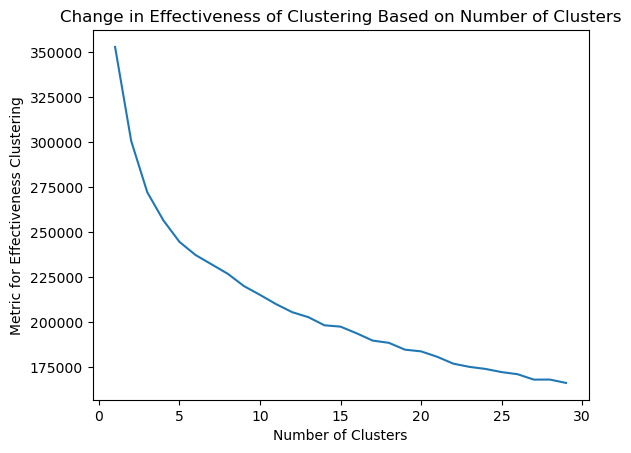

In [88]:
find_num_clusters(df_ftd, 1, 30)

Using Elbow Method, choose 15 clusters

<a id="3"></a>

## Split Data into Batches

In [17]:
batch_size = 250

In [18]:
def prepare_data(df_ftd, num_new):
    train_batches = []
    validation = []
    test = []
    
    X_train, X_val, y_train, y_val = train_test_split(df_ftd, df_ftd, test_size=0.2, random_state=42)

    X_test, X_val, y_test, y_val = train_test_split(X_val, y_val, test_size=0.5, random_state=42)

    for i in range(0, len(X_train), batch_size):
        train_batches.append((X_train[i:i+batch_size, :].astype(np.float32), y_train[i:i+batch_size, :].astype(np.float32)))
        
        '''
        for i in range(num_new):
             new_data = X_train[i:i+batch_size, :] + 0.1*np.random.normal(loc=0.5, scale=0.25, size=X_train[i:i+batch_size, :].shape)
             train_batches.append((new_data.astype(np.float32), y_train[i:i+batch_size, :].astype(np.float32)))
        '''
    for i in range(len(X_val)):
        validation.append((X_val[i, :].astype(np.float32), y_val[i,:].astype(np.float32)))
        
    for i in range(len(X_test)):
        test.append((X_test[i, :].astype(np.float32), y_test[i,:].astype(np.float32)))
        
        
    return train_batches, validation, test

In [19]:
initial_train_batches, initial_val, initial_test = prepare_data(np.array(df_ftd), 2)

In [20]:
initial_train_batches[1][1].shape

(250, 55)

## Pre-Training Loop

In [21]:
num_epochs = 300

In [22]:
def shuffle(x):
    random.shuffle(x)
    for i, j in x:
        k = list(zip(i, j))
        random.shuffle(k)
        i, j = zip(*k)
    return x

In [23]:
def training_loop_non_KL(num_epochs, ae, input_data_train, input_data_validation, input_data_test):
    
    learning_rate = 0.001
    loss_function = nn.MSELoss()
    optimizer = optim.Adam(ae.parameters(), lr=learning_rate)

    training_loss = []
    validation_loss = []

    for epoch in range(num_epochs):
        running_loss = 0.0

        ae.train()
        
        batch_latent_space_train = []
        batch_output_train = []
        
        input_data_train = shuffle(input_data_train)

        with tqdm(input_data_train, unit="batch") as tepoch:
            
            for X, y_true in tepoch:
                

                optimizer.zero_grad()

                X = torch.tensor(X).to(torch.float32)

                y_pred, latent_space_train = ae(X)
                

                y_true = torch.tensor(y_true).to(torch.float32)

                loss = loss_function(y_pred, y_true)

                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                
                batch_latent_space_train.append(latent_space_train)
                batch_output_train.append(y_pred)

        average_loss = running_loss / len(input_data_train)
        #print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {average_loss}")
        training_loss.append(average_loss)

        # Validation loop
        ae.eval()  # Set the model to evaluation mode
        val_loss = 0.0
        with torch.no_grad():

            batch_latent_space_val = []
            batch_output_val = []

            for X_val, y_true_val in input_data_validation:

                X_val = torch.tensor(X_val).to(torch.float32)

                y_pred_val, latent_space_validation = ae(X_val)

                y_true_val = torch.tensor(y_true_val).to(torch.float32)

                loss = loss_function(y_pred_val, y_true_val)
                val_loss += loss.item()
                
                batch_latent_space_val.append(latent_space_validation)
                batch_output_val.append(y_pred_val)


        # Print the validation loss for the epoch.
        average_val_loss = val_loss / len(input_data_validation)
        #print(f"Validation Loss: {average_val_loss} \n")
        validation_loss.append(average_val_loss)

        if epoch == 0:
            min_dev_loss = average_val_loss
            dev_loss_counter = 0
            model = copy.deepcopy(ae)
        else:
            if average_val_loss >= min_dev_loss:
                dev_loss_counter += 1
                if dev_loss_counter > 3:

                    #print("Early Stopping")
                    ae = model
                    break
            else:

                min_dev_loss = average_val_loss
                dev_loss_counter = 0

    # Testing loop
    ae.eval()  # Set the model to evaluation mode
    test_loss = 0.0
    with torch.no_grad():
        
        batch_latent_space_test = []
        batch_output_test = []

        for X_test, y_true_test in input_data_test:

            X_test = torch.tensor(X_test).to(torch.float32)

            y_pred_test, latent_space_test = ae(X_test)
            
            y_true_test = torch.tensor(y_true_test).to(torch.float32)

            loss = loss_function(y_pred_test, y_true_test)

            test_loss += loss.item()
            
            batch_latent_space_test.append(latent_space_test)
            batch_output_test.append(y_pred_test)


    # Print the average test loss
    average_test_loss = test_loss / len(input_data_test)
    #print(f"Average Test Loss: {average_test_loss}")
 
    
    return training_loss, validation_loss

## AE

In [24]:
class AE(nn.Module):
    
    def __init__(self, embedding_size, latent_size):
        super(AE, self).__init__()
        
        self.encode_linear_1 = nn.Linear(embedding_size, latent_size)
        self.decode_linear_1 = nn.Linear(latent_size, embedding_size)
        
    def encode(self, X):
        encoded_X = self.encode_linear_1(X)
        return encoded_X
    
    def decode(self, X):
        decoded_X = self.decode_linear_1(X)
        return decoded_X
    
    def forward(self, X):
        latent_layer = self.encode(X)
        output = self.decode(latent_layer)
        return output, latent_layer

<a id="9"></a>

## KL Fine-Tuning

<a id="10"></a>

### Define Ensemble Encoder Model

In [25]:
class Ensembled_Encoder(nn.Module):
    
    def __init__(self, model):
        super(Ensembled_Encoder, self).__init__()
        self.model = model
        
       
    def forward(self, X):
        
        enc_X = self.model.encode(X)
        return enc_X

<a id="11"></a>

### Define Soft Assignment and Target Distribution Function

In [26]:
softmax = nn.Softmax(dim=0)

In [27]:
def make_P_and_Q(pred, centres):
      
    centres_broadcasted = centres.unsqueeze(0).expand(pred.size(0), -1, -1)
    
    q_numerator = 1/(1+torch.norm(pred.unsqueeze(1) - centres_broadcasted, dim=2)**2)   
    Q = q_numerator / q_numerator.sum(dim=1, keepdim=True)
    
    soft_cluster_frequencies = Q.sum(dim=0)
    p_numerator = Q**2/soft_cluster_frequencies
    P = p_numerator / p_numerator.sum(dim=1, keepdim=True)

    return P, Q

In [28]:
def make_label_P_Q(pred, centres, init_labels, num_clusters):
    
    centres_broadcasted = centres.unsqueeze(0).expand(pred.size(0), -1, -1)
    
    q_numerator = 1/(1+torch.norm(pred.unsqueeze(1) - centres_broadcasted, dim=2)**2)   
    Q = q_numerator / q_numerator.sum(dim=1, keepdim=True)
    
    
    P = np.zeros((init_labels.shape[0], num_clusters))
    
    for i in range(P.shape[0]):
        P[i, init_labels[i]] = 1
        
    P = torch.tensor(P).float()
 
    return P, Q
    

<a id="12"></a>

### Define Training Loop

In [29]:
def training_loop_KL(num_epochs, model, num_clusters, input_data_train, input_data_validation, input_data_test, use_original = None, use_labels = None):

    kl_loss = nn.KLDivLoss(reduction="batchmean")
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
    
    training_loss = []
    validation_loss = []
    
    latent_space = model(torch.from_numpy(df_ftd.to_numpy().astype(np.float32)).to(torch.float32)).detach().numpy()
    
    kmeans = KMeans(n_clusters=num_clusters, n_init='auto').fit(latent_space)
        
    init_centres = kmeans.cluster_centers_
    
    centres = torch.Tensor(init_centres)
    
    old_labels = kmeans.labels_
           
    for epoch in range(num_epochs):
        running_loss = 0.0

        model.train()
        
        batch_output_train = []
        
        input_data_train = shuffle(input_data_train)

        with tqdm(input_data_train, unit="batch") as tepoch:


            for X, y_true in tepoch:

                optimizer.zero_grad()

                X = torch.tensor(X).to(torch.float32)
                
                y_pred = model(X) 
                
                y_pred_detach = y_pred.clone().detach().numpy()
                                                          
                if use_original == True and use_labels == False:
                    
                    P, Q = make_P_and_Q(y_pred, centres) 
                                
                    loss_original = kl_loss(torch.log(Q), P)

                    loss_original.backward()

                    optimizer.step()

                    running_loss += loss_original.item()
                    
                elif use_original == False and use_labels == True:
                    
                    labels = kmeans.predict(y_pred_detach) 
                    
                    P_label, Q_label = make_label_P_Q(y_pred, centres, labels, num_clusters)               
                
                    loss_label = kl_loss(torch.log(Q_label), P_label)

                    loss_label.backward()

                    optimizer.step()

                    running_loss += loss_label.item()
                    
                elif use_original == True and use_labels == True:
                    
                    labels = kmeans.predict(y_pred_detach) 
                    
                    P_label, Q_label = make_label_P_Q(y_pred, centres, labels, num_clusters) 
                
                    P_original, Q_original = make_P_and_Q(y_pred, centres)

                    loss_label = kl_loss(torch.log(Q_label), P_label)

                    loss_original = kl_loss(torch.log(Q_original), P_original)

                    loss_label.backward(retain_graph = True)
                    loss_original.backward(retain_graph = True)

                    optimizer.step()

                    running_loss += (loss_label + loss_original).item()
                
                else: 
                    
                    return "Not Possible: Please select True for at least one"


        average_loss = running_loss / len(input_data_train)
        #print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {average_loss}")
        training_loss.append(average_loss)
        
        # Validation loop
        model.eval()  # Set the model to evaluation mode
        val_loss = 0.0
        with torch.no_grad():

            batch_output_val = []

            for X_val, y_true_val in input_data_validation:

                X_val = torch.tensor(X_val).to(torch.float32)

                y_pred_val = model(X_val)
                
                y_pred_val = y_pred_val.unsqueeze(0)
                                
                y_pred_detach_val = y_pred_val.clone().detach().numpy()    
                
                if use_original == True and use_labels == False:      
                                      
                    P_val, Q_val = make_P_and_Q(y_pred_val, centres)

                    loss_val_original = kl_loss(torch.log(Q_val), P_val)

                    val_loss += loss_val_original.item()
                
                elif use_original == False and use_labels == True:
                    
                    labels_val = kmeans.predict(y_pred_detach_val) 
                    
                    P_val_labels, Q_val_labels = make_label_P_Q(y_pred_val, centres, labels_val, num_clusters)
                                                               
                    loss_val_labels = kl_loss(torch.log(Q_val_labels), P_val_labels)

                    val_loss += loss_val_labels.item()
                    
                elif use_original == True and use_labels == True:
                    
                    labels_val = kmeans.predict(y_pred_detach_val)
                    
                    P_val_labels, Q_val_labels = make_label_P_Q(y_pred_val, centres, labels_val, num_clusters)
                                                          
                    P_val_original, Q_val_original = make_P_and_Q(y_pred_val, centres)

                    loss_val_labels = kl_loss(torch.log(Q_val_labels), P_val_labels)

                    loss_val_original = kl_loss(torch.log(Q_val_original), P_val_original)

                    val_loss += (loss_val_labels + loss_val_original).item()
                
                else:
                    return "Not Possible"
              
        # Print the validation loss for the epoch.
        average_val_loss = val_loss / len(input_data_validation)
        #print(f"Validation Loss: {average_val_loss} \n")
        validation_loss.append(average_val_loss)
                       
        output = model(torch.from_numpy(df_ftd.to_numpy().astype(np.float32)).to(torch.float32)).detach().numpy()
        
        kmeans = KMeans(n_clusters=num_clusters, n_init='auto').fit(output)
        
        #print(kmeans.inertia_)
        
        centres = torch.Tensor(kmeans.cluster_centers_)
        
        if epoch == 0:
            min_dev_loss = average_val_loss
            dev_loss_counter = 0
            model_stored = copy.deepcopy(model)
        else:
            if average_val_loss >= min_dev_loss:
                dev_loss_counter += 1
                if dev_loss_counter > 3:
                    #print("Early Stopping")
                    model = model_stored
                    break
            else:
                min_dev_loss = average_val_loss
                dev_loss_counter = 0
                model_stored = copy.deepcopy(model)
        
            
    # Testing loop
    model.eval()  # Set the model to evaluation mode
    test_loss = 0.0
    with torch.no_grad():

        batch_output_test = []

        for X_test, y_true_test in input_data_test:

            X_test = torch.tensor(X_test).to(torch.float32)

            y_pred_test = model(X_test)

            y_pred_test = y_pred_test.unsqueeze(0)

            y_pred_detach_test = y_pred_test.clone().detach().numpy()
            
            if use_original == True and use_labels == False:
                
                P_test, Q_test = make_P_and_Q(y_pred_test, centres)

                loss_test_original = kl_loss(torch.log(Q_test), P_test)

                test_loss += loss_test_original.item()
            
            elif use_original == False and use_labels == True: 
                
                labels_test = kmeans.predict(y_pred_detach_test)
                
                P_test_labels, Q_test_labels = make_label_P_Q(y_pred_test, centres, labels_test, num_clusters)

                loss_test_labels = kl_loss(torch.log(Q_test_labels), P_test_labels)

                test_loss += loss_test_labels.item()
                
            elif use_original == True and use_labels == True:
                
                labels_test = kmeans.predict(y_pred_detach_test)
                
                P_test_labels, Q_test_labels = make_label_P_Q(y_pred_test, centres, labels_test, num_clusters)
            
                P_test_original, Q_test_original = make_P_and_Q(y_pred_test, centres)

                loss_test_labels = kl_loss(torch.log(Q_test_labels), P_test_labels)

                loss_test_original = kl_loss(torch.log(Q_test_original), P_test_original)

                test_loss += (loss_test_labels + loss_test_original).item()
                    
    # Print the average test loss
    average_test_loss = test_loss / len(input_data_test)
    #print(f"Average Test Loss: {average_test_loss}")
                
    return training_loss, validation_loss

In [30]:
def training_loop_KL_kmeans_constrained(num_epochs, model, num_clusters, input_data_train, input_data_validation, input_data_test):
    
    model_copy = copy.deepcopy(model)
    
    kl_loss = nn.KLDivLoss(reduction="batchmean")
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
    
    training_loss = []
    validation_loss = []
    
    latent_space = model(torch.from_numpy(df_ftd.to_numpy().astype(np.float32)).to(torch.float32)).detach().numpy()
    
    #kmeans = KMeans(n_clusters=num_clusters, n_init='auto').fit(latent_space)
    kmeans = KMeansConstrained(n_clusters=num_clusters, size_min=200, n_init=10, random_state=0).fit(latent_space)
    
    stored_inertia = kmeans.inertia_
    
    store_labels = kmeans.labels_
            
    init_centres = kmeans.cluster_centers_
    
    centres = torch.Tensor(init_centres)
    
    svc = SVC().fit(latent_space, store_labels)
           
    for epoch in range(num_epochs):
        running_loss = 0.0

        model.train()
        
        batch_output_train = []
        
        input_data_train = shuffle(input_data_train)

        with tqdm(input_data_train, unit="batch") as tepoch:


            for X, y_true in tepoch:

                optimizer.zero_grad()

                X = torch.tensor(X).to(torch.float32)
                
                y_pred = model(X) 
                
                y_pred_detach = y_pred.clone().detach().numpy()
                
                batch_labels = svc.predict(y_pred_detach)                
                                
                P_label, Q_label = make_label_P_Q(y_pred, centres, batch_labels, num_clusters)
                                                                                
                loss_label = kl_loss(torch.log(Q_label), P_label)
                                
                loss_label.backward()
                
                optimizer.step()

                running_loss += loss_label.item()
                

        average_loss = running_loss / len(input_data_train)
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {average_loss}")
        training_loss.append(average_loss)
        
        # Validation loop
        model.eval()  # Set the model to evaluation mode
        val_loss = 0.0
        with torch.no_grad():

            batch_output_val = []

            for X_val, y_true_val in input_data_validation:

                X_val = torch.tensor(X_val).to(torch.float32)

                y_pred_val = model(X_val)
                
                y_pred_val = y_pred_val.unsqueeze(0)
                                
                y_pred_detach_val = y_pred_val.clone().detach().numpy()
                
                batch_labels_val = svc.predict(y_pred_detach_val)                
                                
                P_val_labels, Q_val_labels = make_label_P_Q(y_pred_val, centres, batch_labels_val, num_clusters)
                                                                
                P_val, Q_val = make_P_and_Q(y_pred_val, centres)
                
                loss_val_labels = kl_loss(torch.log(Q_val_labels), P_val_labels)
                
                val_loss += loss_val_labels.item()
                
                
        # Print the validation loss for the epoch.
        average_val_loss = val_loss / len(input_data_validation)
        print(f"Validation Loss: {average_val_loss} \n")
        validation_loss.append(average_val_loss)
                        
               
        output = model(torch.from_numpy(df_ftd.to_numpy().astype(np.float32)).to(torch.float32)).detach().numpy()
        
        kmeans_new = KMeansConstrained(n_clusters=num_clusters, size_min=200, n_init=10, random_state=0).fit(output)
                
        print(kmeans_new.inertia_)
        
        if kmeans_new.inertia_ < stored_inertia:
            print("good")
            stored_inertia = kmeans_new.inertia_

            svc = SVC().fit(output, kmeans_new.labels_)
            centres = torch.Tensor(kmeans_new.cluster_centers_)
        else:
            print("bad")
            kmeans_unconstrained = KMeans(n_clusters=num_clusters, n_init=10, random_state=0).fit(output)
            
            svc = SVC().fit(output, kmeans_unconstrained.labels_)
            centres = torch.Tensor(kmeans_unconstrained.cluster_centers_)

        
        if epoch == 0:
            kmeans_inertia = kmeans.inertia_
            model_store = copy.deepcopy(model)
            inertia_count = 0
        elif epoch > 10:
            if kmeans.inertia_ > kmeans_inertia:
                inertia_count += 1
                if inertia_count > 3:
                    #print("Early Stopping")
                    model = model_store
                    if kmeans.inertia_ > 10:
                        return training_loop_KL_kmeans_constrained(num_epochs, model_copy, num_clusters, input_data_train, input_data_validation, input_data_test)

                    break
                else:
                    kmeans_inertia = kmeans.inertia_
                    model_store = copy.deepcopy(model)
                    
            else:
                kmeans_inertia = kmeans.inertia_
                model_store = copy.deepcopy(model)
        else:
            kmeans_inertia = kmeans.inertia_
            model_store = copy.deepcopy(model)
                
    # Testing loop
    model.eval()  # Set the model to evaluation mode
    test_loss = 0.0
    with torch.no_grad():

        batch_output_test = []

        for X_test, y_true_test in input_data_test:

            X_test = torch.tensor(X_test).to(torch.float32)

            y_pred_test = model(X_test)

            y_pred_test = y_pred_test.unsqueeze(0)

            y_pred_detach_test = y_pred_test.clone().detach().numpy()

            labels_test = svc.predict(y_pred_detach_test)                

            P_test_labels, Q_test_labels = make_label_P_Q(y_pred_test, centres, labels_test, num_clusters)

            P_test, Q_test = make_P_and_Q(y_pred_test, centres)

            loss_test_labels = kl_loss(torch.log(Q_test_labels), P_test_labels)

            test_loss += loss_test_labels.item()
            
    # Print the average test loss
    average_test_loss = test_loss / len(input_data_test)
    #print(f"Average Test Loss: {average_test_loss}")

    return training_loss, validation_loss

## Training Functions

In [31]:
def train_ae_original(ae, num_clusters, num_epochs):

    ae_original = copy.deepcopy(ae)

    ae_original_enc = Ensembled_Encoder(ae_original)
    training_loss, validation_loss = training_loop_KL(num_epochs, ae_original_enc, num_clusters, 
                                                      initial_train_batches, initial_val, 
                                                      initial_test, use_original = True, use_labels = False)
    
    return ae_original_enc, training_loss, validation_loss

In [32]:
def train_ae_label(ae, num_clusters, num_epochs):
    
    ae_label = copy.deepcopy(ae)

    ae_label_enc = Ensembled_Encoder(ae_label)
    training_loss, validation_loss = training_loop_KL(num_epochs, ae_label_enc, num_clusters, 
                                                            initial_train_batches, initial_val, 
                                                            initial_test, use_original = False, use_labels = True)
    
    return ae_label_enc, training_loss, validation_loss 

In [33]:
def train_ae_original_label(ae, num_clusters, num_epochs):
    ae_original_label = copy.deepcopy(ae)

    ae_original_label_enc = Ensembled_Encoder(ae_original_label)
    training_loss, validation_loss = training_loop_KL(num_epochs, ae_original_label_enc, num_clusters, 
                                        initial_train_batches, initial_val, 
                                        initial_test, use_original = True, use_labels = False)
    
    return ae_original_label_enc, training_loss, validation_loss 

In [34]:
def train_ae_constrained(ae, num_clusters, num_epochs):
    ae_constrained = copy.deepcopy(ae)

    ae_constrained_enc = Ensembled_Encoder(ae_constrained)
    training_loss, validation_loss = training_loop_KL_kmeans_constrained(num_epochs, ae_constrained_enc, num_clusters, initial_train_batches, initial_val, initial_test)
    
    return ae_constrained_enc, training_loss, validation_loss 

## Metric Functions

In [35]:
def get_normal_kmeans(num_clusters):
    
    normal_kmeans = KMeans(n_clusters=num_clusters, random_state=0, n_init='auto').fit(df_ftd)

    normal_labels = normal_kmeans.fit_predict(df_ftd)

    normal_inertia = normal_kmeans.inertia_

    normal_sil = silhouette_score(df_ftd, normal_labels)
    
    return normal_inertia, normal_sil, normal_kmeans

In [37]:
def get_pca_kmeans(num_clusters, num_components):
    pca = PCA(n_components= num_components)  
    pca.fit(df_ftd)
    df_ftd_PCA_reduced = pca.transform(df_ftd)

    pca_emb_kmeans = KMeans(n_clusters=12, random_state=0, n_init='auto').fit(df_ftd_PCA_reduced)

    pca_inertia = pca_emb_kmeans.inertia_

    pca_labels = pca_emb_kmeans.fit_predict(df_ftd_PCA_reduced)

    pca_sil = silhouette_score(df_ftd_PCA_reduced, pca_labels)
    
    return pca_inertia, pca_sil, pca_emb_kmeans

In [38]:
def get_constrained_kmeans(num_clusters):
    
    constrained_kmeans = KMeansConstrained(n_clusters=num_clusters, size_min=200, n_init=10, random_state=0).fit(df_ftd)

    constrained_labels = constrained_kmeans.fit_predict(df_ftd)

    constrained_inertia = constrained_kmeans.inertia_

    constrained_sil = silhouette_score(df_ftd, constrained_labels)
    
    return constrained_inertia, constrained_sil, constrained_kmeans

In [39]:
def get_non_KL_deep_cluster_metrics(model, num_clusters):
    
    embedded_df_ftd = model.encode(torch.from_numpy(df_ftd.to_numpy().astype(np.float32)).to(torch.float32)).detach().numpy()
    
    deep_emb_kmeans = KMeans(n_clusters=num_clusters, random_state=0, n_init='auto').fit(embedded_df_ftd)
    
    deep_labels = deep_emb_kmeans.fit_predict(embedded_df_ftd)
    sil_score = silhouette_score(embedded_df_ftd, deep_labels)
    
    inertia = deep_emb_kmeans.inertia_
    
    return inertia, sil_score

In [41]:
def get_KL_deep_cluster_metrics(model, num_clusters):
    
    embedded_df_ftd = model(torch.from_numpy(df_ftd.to_numpy().astype(np.float32)).to(torch.float32)).detach().numpy()
    
    deep_emb_kmeans = KMeans(n_clusters=num_clusters, n_init='auto').fit(embedded_df_ftd)
    
    deep_labels = deep_emb_kmeans.fit_predict(embedded_df_ftd)
    sil_score = silhouette_score(embedded_df_ftd, deep_labels)
    
    inertia = deep_emb_kmeans.inertia_
    
    return inertia, sil_score
    

In [42]:
def get_all_model_metrics(num_repeats = None, num_clusters = None, num_epochs = None, num_components = None, embedding_size = None, latent_size = None):
        
    model_inertia_evaluation = {
        'kmeans': [],
        'pca_kmeans': [],
        'constrained_kmeans': [],
        'ae': [],
        'ae_original': [],
        'ae_label': [],
        'ae_original_label': [],
        'ae_constrained': []
    }
    
    
    model_sil_evaluation = {
        'kmeans': [],
        'pca_kmeans': [],
        'constrained_kmeans': [],
        'ae': [],
        'ae_original': [],
        'ae_label': [],
        'ae_original_label': [],
        'ae_constrained': []
    }
    
    
    training_losses = {
        'ae': [],
        'ae_original': [],
        'ae_label': [],
        'ae_original_label': [],
        'ae_constrained': []
    }
    
    validation_losses = {
        'ae': [],
        'ae_original': [],
        'ae_label': [],
        'ae_original_label': [],
        'ae_constrained': []
    }
    
    
    models = {
        'kmeans': [],
        'pca_kmeans': [],
        'constrained_kmeans': [],
        'ae': [],
        'ae_original': [],
        'ae_label': [],
        'ae_original_label': [],
        'ae_constrained': []
    }
    
    for i in range(num_repeats):
            
            
            normal_inertia, normal_sil, normal_kmeans = get_normal_kmeans(num_clusters)
            model_inertia_evaluation['kmeans'].append(normal_inertia)
            model_sil_evaluation['kmeans'].append(normal_sil)
            models['kmeans'].append(normal_kmeans)
            
            pca_inertia, pca_sil, pca_kmeans = get_pca_kmeans(num_clusters, num_components)
            model_inertia_evaluation['pca_kmeans'].append(pca_inertia)
            model_sil_evaluation['pca_kmeans'].append(pca_sil)
            models['pca_kmeans'].append(pca_kmeans)
            
            constrained_inertia, constrained_sil, constrained_kmeans = get_constrained_kmeans(num_clusters)
            model_inertia_evaluation['constrained_kmeans'].append(constrained_inertia)
            model_sil_evaluation['constrained_kmeans'].append(constrained_sil)
            models['constrained_kmeans'].append(constrained_kmeans)
            
            
            ae = AE(embedding_size, latent_size)
            ae_training_loss, ae_validation_loss = training_loop_non_KL(num_epochs, ae, initial_train_batches, initial_val, initial_test)
            training_losses['ae'].append(ae_training_loss)
            validation_losses['ae'].append(ae_validation_loss)
            ae_stored = copy.deepcopy(ae)
            ae_non_kl_inertia, ae_non_kl_sil = get_non_KL_deep_cluster_metrics(ae_stored, num_clusters)
            model_inertia_evaluation['ae'].append(ae_non_kl_inertia)
            model_sil_evaluation['ae'].append(ae_non_kl_sil)
            models['ae'].append(ae)
                        
                        
            ae_original_enc, ae_original_training_loss, ae_original_validation_loss = train_ae_original(ae, num_clusters, num_epochs)
            training_losses['ae_original'].append(ae_original_training_loss)
            validation_losses['ae_original'].append(ae_original_validation_loss)
            models['ae_original'].append(ae_original_enc)
            
            
            ae_label_enc, ae_label_training_loss, ae_label_validation_loss  = train_ae_label(ae, num_clusters, num_epochs)
            training_losses['ae_label'].append(ae_label_training_loss)
            validation_losses['ae_label'].append(ae_label_validation_loss)
            models['ae_label'].append(ae_label_enc)
            
            ae_original_label_enc, ae_original_label_training_loss, ae_original_label_validation_loss = train_ae_original_label(ae, num_clusters, num_epochs)
            training_losses['ae_original_label'].append(ae_original_label_training_loss)
            validation_losses['ae_original_label'].append(ae_original_label_validation_loss)
            models['ae_original_label'].append(ae_original_label_enc)
                    
            ae_constrained = AE(embedding_size, latent_size)
            ae_constrained_training_loss, ae_constrained_validation_loss = training_loop_non_KL(10, ae_constrained, initial_train_batches, initial_val, initial_test)

            
            ae_constrained_enc, ae_constrained_enc_training_loss, ae_constrained_enc_validation_loss = train_ae_constrained(ae_constrained, num_clusters, num_epochs)
            training_losses['ae_constrained'].append(ae_constrained_enc_training_loss)
            validation_losses['ae_constrained'].append(ae_constrained_enc_validation_loss)
            models['ae_constrained'].append(ae_constrained_enc)
            
            
            ae_kl_original_inertia, ae_kl_original_sil = get_KL_deep_cluster_metrics(ae_original_enc, num_clusters)
            ae_kl_label_inertia, ae_kl_label_sil = get_KL_deep_cluster_metrics(ae_label_enc, num_clusters)
            ae_kl_original_label_inertia, ae_kl_original_label_sil = get_KL_deep_cluster_metrics(ae_original_label_enc, num_clusters)
            ae_kl_constrained_inertia, ae_kl_constrained_sil = get_KL_deep_cluster_metrics(ae_constrained_enc, num_clusters)
            
            model_inertia_evaluation['ae_original'].append(ae_kl_original_inertia)
            model_sil_evaluation['ae_original'].append(ae_kl_original_sil)
            
            model_inertia_evaluation['ae_label'].append(ae_kl_label_inertia)
            model_sil_evaluation['ae_label'].append(ae_kl_label_sil)
            
            model_inertia_evaluation['ae_original_label'].append(ae_kl_original_label_inertia)
            model_sil_evaluation['ae_original_label'].append(ae_kl_original_label_sil)
            
            model_inertia_evaluation['ae_constrained'].append(ae_kl_constrained_inertia)
            model_sil_evaluation['ae_constrained'].append(ae_kl_constrained_sil)
            
            print("Finished Instance ", i)
    
    #get models, training and validation loop for max sil score
    for i in model_sil_evaluation.keys():
        
        models[i] = models[i][model_sil_evaluation[i].index(max(model_sil_evaluation[i]))]
        
        if 'ae' in i:  
            training_losses[i] = training_losses[i][model_sil_evaluation[i].index(max(model_sil_evaluation[i]))]
            validation_losses[i] = validation_losses[i][model_sil_evaluation[i].index(max(model_sil_evaluation[i]))]
    
            
    for i in model_inertia_evaluation.keys():
        model_inertia_evaluation[i] = sum(model_inertia_evaluation[i])/len(model_inertia_evaluation[i])
        
    for i in model_sil_evaluation.keys():
        model_sil_evaluation[i] = sum(model_sil_evaluation[i])/len(model_sil_evaluation[i])
            
    return model_inertia_evaluation, model_sil_evaluation, training_losses, validation_losses, models
            

In [ ]:
model_inertia_evaluation, model_sil_evaluation, training_losses, validation_losses, models = get_all_model_metrics( num_repeats = 1, num_clusters = 15, 
                                                                                                                    num_epochs = 20, num_components = 10, 
                                                                                                                    embedding_size = 55, latent_size = 10)

In [51]:
model_inertia_evaluation

{'kmeans': 185928.8024599911,
 'pca_kmeans': 113831.22808037642,
 'constrained_kmeans': 185362.19581117432,
 'ae': 50115.76953125,
 'ae_original': 463.5526123046875,
 'ae_label': 2.8229498863220215,
 'ae_original_label': 363.11529541015625,
 'ae_constrained': 2.2393927574157715}

In [53]:
model_sil_evaluation

{'kmeans': 0.12082081425827153,
 'pca_kmeans': 0.1876089031633407,
 'constrained_kmeans': 0.13939471219038055,
 'ae': 0.2689826190471649,
 'ae_original': 0.1640891581773758,
 'ae_label': 0.9992978572845459,
 'ae_original_label': 0.1250217854976654,
 'ae_constrained': 0.9993568062782288}

## Deep Table

In [54]:
embedded_df_ftd = models['ae_constrained'](torch.from_numpy(df_ftd.to_numpy()).to(torch.float32)).detach().numpy()
    
deep_emb_kmeans = KMeansConstrained(n_clusters=12, size_min=200, n_init=10, random_state=0).fit(embedded_df_ftd)

df_ftd_pre_encoding['AE_Constrained'] = deep_emb_kmeans.fit_predict(embedded_df_ftd)

In [55]:
df_ftd_pre_encoding.to_csv('/home/tom/Documents/ParlayPlay/Cluster_EDA/constrained_clusters_binned_data.csv') 